In [1]:
import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import ListedColormap, LinearSegmentedColormap


In [2]:
plt.rcParams.update({
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "font.family": "sans-serif", "axes.linewidth": 0.7, "xtick.major.width": 0.7,
    "ytick.major.width": 0.7, "xtick.major.size": 3.0, "ytick.major.size": 3.0, "savefig.dpi": 600,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

hexcolors = [
    '#D1B8D7', '#AE76A3', '#882E72',
    '#1965B0', '#5289C7', '#7BAFDE',
    '#4EB265', '#90C987', '#CAE0AB',
    '#F7F056', '#F6C141', '#F1932D',
    '#E8601C', '#DC050C', '#777777',
    '#000000'
]
 
colornames = [
    'purple1','purple2','purple3',
    'blue1','blue2','blue3',
    'green1','green2','green3',
    'yellow1','yellow2','orange1',
    'orange2','red','grey', 'black'
]
 
rnb_colors = dict(zip(colornames, hexcolors))

rnb_cmap = ListedColormap(hexcolors, name="rnb")

rnb_cmap_cont = LinearSegmentedColormap.from_list(
    "rnb_continuous",
    hexcolors[::-1],
    N=256  # smoothness
)

In [3]:
martini_ddg_dict = {
    'A': 0,
    'R': -1.37731302709215,
    'N': -2.7177875258719233,
    'D': -1.0840721633560904,
    'C': -0.414182447252168,
    'Q': -1.9643353618979944,
    'E': -1.5508479812177551,
    'G': -1.2698866269191544,
    'H': 0.0088041765778044,
    'I': 4.608291371906956,
    'L': 5.267060022859969,
    'K': -0.7224830867134155,
    'M': -0.414182447252168,
    'F': 12.230700318186033,
    'P': 7.555373636897224,
    'S': -1.828951839609525,
    'T': -1.828951839609525,
    'W': 9.54581261005221,
    'Y': 3.727873714126844,
    'V': 1.7165055141948038
}

exp_ddg_dict = {
    'A': 0,
    'R': -3.4308799999999997,
    'N': -1.045999999999999,
    'D': -4.435040000000001,
    'C': 1.715440000000001,
    'Q': -1.715440000000001,
    'E': -7.740400000000001,
    'G': 0.6694400000000016,
    'H': 0,
    'I': 1.840959999999999,
    'L': 3.054319999999997,
    'K': -4.184,
    'M': 1.6736000000000004,
    'F': 5.4392,
    'P': -1.171520000000001,
    'S': 0.16735999999999862,
    'T': 0.12552000000000163,
    'W': 8.45168,
    'Y': 4.64424,
    'V': 0.41839999999999833
}

kcal_to_kj = 4.184

ww_dict = {
    "Ala": {"value": 4.08, "error": 0.03},
    "Arg": {"value": 3.91, "error": 0.02},
    "Asn": {"value": 3.83, "error": 0.04},
    "Asp": {"value": 3.02, "error": 0.04},
    "Cys": {"value": 4.49, "error": 0.04},
    "Gln": {"value": 3.67, "error": 0.06},
    "Glu": {"value": 2.23, "error": 0.10},
    "Gly": {"value": 4.24, "error": 0.02},
    "His": {"value": 4.08, "error": 0.02},
    "Ile": {"value": 4.52, "error": 0.03},
    "Leu": {"value": 4.81, "error": 0.02},
    "Lys": {"value": 3.77, "error": 0.12},
    "Met": {"value": 4.48, "error": 0.04},
    "Phe": {"value": 5.38, "error": 0.02},
    "Pro": {"value": 3.80, "error": 0.11},
    "Ser": {"value": 4.12, "error": 0.07},
    "Thr": {"value": 4.11, "error": 0.03},
    "Trp": {"value": 6.10, "error": 0.02},
    "Tyr": {"value": 5.19, "error": 0.04},
    "Val": {"value": 4.18, "error": 0.02},
}
df_residues = pd.read_csv('data/WLXLL/residues.csv',index_col=1)
df_dGww = pd.DataFrame(ww_dict).T
df_dGww['one'] = df_dGww.index.map(lambda x: df_residues.loc[x.upper()].one)
df_dGww = df_dGww.set_index('one')[['value','error']]
df_dGww[['value','error']] *= kcal_to_kj


In [4]:
# Minimum detection

aas = list("ACDEGHIKLMNPQRSTV")
temps = ["323"]              
hpcs = ["Tetralith", "Arrhenius"]

discard = 1000 
bins = np.linspace(-146, 8, 154)

energies = {}

for aa in aas:
    energies[aa] = {}
    for t in temps:
        all_ene = []
        for hpc in hpcs:
            file = f"data/WLXLL/{t}/{hpc}_WL{aa}LL_pl.npy"
            ene = np.load(file, allow_pickle=True)
            all_ene.append(ene[discard:])
        if all_ene:
            energies[aa][t] = np.concatenate(all_ene)
            hist, edges = np.histogram(ene, bins=bins, density=True)
            centers = edges[:-1] + 0.5 * np.diff(edges)
            mask = (centers >= -50) & (centers <= -1)
            mins = []
            min_idx = np.argmin(hist[mask])
            mins.append(centers[mask][min_idx])
min_avg = np.mean(mins)
print(f"Mean minimum position: {min_avg:.3f} kJ/mol")

Mean minimum position: -19.680 kJ/mol


In [5]:
threshold = min_avg
results = []

aas = list("ACDEGHIKLMNPQRSTVFYW")
ts = ['303', '323']
hpcs = ['Tetralith', 'Arrhenius']

for a in aas:
    for t in ts:

        t = int(t)
        RT_to_kJ_per_mol = t * 8.3145e-3

        dg_hpc = {}
        valid_data = True

        for hpc in hpcs:

            ene = np.load(f'data/WLXLL/{t}/{hpc}_WL{a}LL_pl.npy', allow_pickle=True)[1000:]

            f_bound = np.sum(ene < threshold) / len(ene)
            f_unbound = 1 - f_bound

            if f_bound == 0 or f_unbound == 0:
                valid_data = False
                break

            val = RT_to_kJ_per_mol * np.log(f_bound / f_unbound)

            if not np.isfinite(val):
                valid_data = False
                break

            dg_hpc[hpc] = val

        if not valid_data or len(dg_hpc) < len(hpcs):
            continue

        dg_avg = np.mean(list(dg_hpc.values()))
        dg_err = np.abs(dg_hpc['Arrhenius'] - dg_hpc['Tetralith'])/2

        results.append({
            'aa': a,
            'T': t,
            'dg': dg_avg,
            'dg_err': dg_err
        })

df_sim = pd.DataFrame(results)

print(df_sim.to_string(index=False))

aa   T        dg   dg_err
 A 303  7.603298 0.035140
 A 323  6.085239 0.076605
 C 303  7.888712 0.203398
 C 323  5.186439 0.070666
 D 303  4.444825 0.077855
 D 323  3.138462 0.087066
 E 303  4.044832 0.451332
 E 323  2.351279 0.051963
 G 303  8.055944 0.426932
 G 323  7.257607 0.361675
 H 303  5.402137 0.033276
 H 323  4.046875 0.295105
 I 323 26.846025 4.070030
 K 303  6.445065 0.379485
 K 323  5.014397 0.469161
 L 303 29.252913 3.230968
 L 323 26.702581 3.409525
 M 323 22.693334 1.216447
 N 303  7.121661 0.402935
 N 323  5.043210 0.022890
 P 303  5.571467 0.015762
 P 323  5.651432 0.346690
 Q 303  5.400860 0.508144
 Q 323  4.579735 0.344980
 R 303  6.683114 0.489489
 R 323  5.491174 0.080368
 S 303  7.177241 0.145017
 S 323  6.030084 0.059058
 T 303  5.850682 0.139701
 T 323  5.132483 0.230861
 V 303 18.994517 1.473969
 V 323 19.576221 2.379049


In [6]:
df_dGww = pd.DataFrame(ww_dict).T
df_dGww[['value', 'error']] *= 4.184

df_dGww["aa"] = df_dGww.index.map(
    lambda x: df_residues.loc[x.upper()].one
)

df_exp = df_dGww.rename(
    columns={
        "value": "exp",
        "error": "exp_error"
    }
)[["aa", "exp", "exp_error"]]


# merge reference values
df = df_sim.merge(df_exp, on="aa", how="left")

print(df.to_string(index=False))

aa   T        dg   dg_err      exp  exp_error
 A 303  7.603298 0.035140 17.07072    0.12552
 A 323  6.085239 0.076605 17.07072    0.12552
 C 303  7.888712 0.203398 18.78616    0.16736
 C 323  5.186439 0.070666 18.78616    0.16736
 D 303  4.444825 0.077855 12.63568    0.16736
 D 323  3.138462 0.087066 12.63568    0.16736
 E 303  4.044832 0.451332  9.33032    0.41840
 E 323  2.351279 0.051963  9.33032    0.41840
 G 303  8.055944 0.426932 17.74016    0.08368
 G 323  7.257607 0.361675 17.74016    0.08368
 H 303  5.402137 0.033276 17.07072    0.08368
 H 323  4.046875 0.295105 17.07072    0.08368
 I 323 26.846025 4.070030 18.91168    0.12552
 K 303  6.445065 0.379485 15.77368    0.50208
 K 323  5.014397 0.469161 15.77368    0.50208
 L 303 29.252913 3.230968 20.12504    0.08368
 L 323 26.702581 3.409525 20.12504    0.08368
 M 323 22.693334 1.216447 18.74432    0.16736
 N 303  7.121661 0.402935 16.02472    0.16736
 N 323  5.043210 0.022890 16.02472    0.16736
 P 303  5.571467 0.015762 15.89920

In [7]:
df_martini = pd.DataFrame.from_dict(martini_ddg_dict, orient='index', columns=['ddg_martini'])

df = df.merge(df_martini, left_on='aa', right_index=True, how='left')
print(df.to_string(index=False))

aa   T        dg   dg_err      exp  exp_error  ddg_martini
 A 303  7.603298 0.035140 17.07072    0.12552     0.000000
 A 323  6.085239 0.076605 17.07072    0.12552     0.000000
 C 303  7.888712 0.203398 18.78616    0.16736    -0.414182
 C 323  5.186439 0.070666 18.78616    0.16736    -0.414182
 D 303  4.444825 0.077855 12.63568    0.16736    -1.084072
 D 323  3.138462 0.087066 12.63568    0.16736    -1.084072
 E 303  4.044832 0.451332  9.33032    0.41840    -1.550848
 E 323  2.351279 0.051963  9.33032    0.41840    -1.550848
 G 303  8.055944 0.426932 17.74016    0.08368    -1.269887
 G 323  7.257607 0.361675 17.74016    0.08368    -1.269887
 H 303  5.402137 0.033276 17.07072    0.08368     0.008804
 H 323  4.046875 0.295105 17.07072    0.08368     0.008804
 I 323 26.846025 4.070030 18.91168    0.12552     4.608291
 K 303  6.445065 0.379485 15.77368    0.50208    -0.722483
 K 323  5.014397 0.469161 15.77368    0.50208    -0.722483
 L 303 29.252913 3.230968 20.12504    0.08368     5.2670

In [8]:
df_ww_ddg = pd.DataFrame.from_dict(exp_ddg_dict, orient='index', columns=['exp_ddg'])

df = df.merge(df_ww_ddg, left_on='aa', right_index=True, how='left')
print(df.to_string(index=False))

aa   T        dg   dg_err      exp  exp_error  ddg_martini  exp_ddg
 A 303  7.603298 0.035140 17.07072    0.12552     0.000000  0.00000
 A 323  6.085239 0.076605 17.07072    0.12552     0.000000  0.00000
 C 303  7.888712 0.203398 18.78616    0.16736    -0.414182  1.71544
 C 323  5.186439 0.070666 18.78616    0.16736    -0.414182  1.71544
 D 303  4.444825 0.077855 12.63568    0.16736    -1.084072 -4.43504
 D 323  3.138462 0.087066 12.63568    0.16736    -1.084072 -4.43504
 E 303  4.044832 0.451332  9.33032    0.41840    -1.550848 -7.74040
 E 323  2.351279 0.051963  9.33032    0.41840    -1.550848 -7.74040
 G 303  8.055944 0.426932 17.74016    0.08368    -1.269887  0.66944
 G 323  7.257607 0.361675 17.74016    0.08368    -1.269887  0.66944
 H 303  5.402137 0.033276 17.07072    0.08368     0.008804  0.00000
 H 323  4.046875 0.295105 17.07072    0.08368     0.008804  0.00000
 I 323 26.846025 4.070030 18.91168    0.12552     4.608291  1.84096
 K 303  6.445065 0.379485 15.77368    0.50208   

In [9]:
omega_2 = {"E", "R", "D", "N", "K", "H", "Q", "S", "C", "T", "A", "P"}
omega_5 = {"G"}
omega_1 = {"M", "F", "Y", "W", "L", "I", "V"}
category_colors = {"omega_2": rnb_colors["blue1"], "omega_5": rnb_colors["orange2"], "omega_1": rnb_colors["purple3"]}

def aa_group(aa: str) -> str:
    if aa in omega_2: return "omega_2"
    if aa in omega_5: return "omega_5"
    if aa in omega_1: return "omega_1"

def aa_color(aa: str) -> str: 
    return category_colors[aa_group(aa)]

def pearsonr_bootstrapped(x: np.ndarray, y: np.ndarray, n_bootstraps: int = 10000, seed: int = 42) -> tuple[float, float]:
    """Calculates Pearson r and its bootstrapped standard error."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n_samples = len(x)

    # Original correlation
    r_orig = pearsonr(x, y)[0]

    # Vectorized bootstrap resampling
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_samples, size=(n_bootstraps, n_samples), replace=True)
    x_boot, y_boot = x[idx], y[idx]

    dx = x_boot - np.mean(x_boot, axis=1, keepdims=True)
    dy = y_boot - np.mean(y_boot, axis=1, keepdims=True)

    cov = np.sum(dx * dy, axis=1)
    var_x = np.sum(dx**2, axis=1)
    var_y = np.sum(dy**2, axis=1)

    r_boot = cov / np.sqrt(var_x * var_y)
    return float(r_orig), float(np.std(r_boot, ddof=1))


def compute_statistics(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    """Computes Pearson r, bootstrapped error on r, and RMSE."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    rmse = float(np.sqrt(np.mean((x - y) ** 2)))
    r, r_err = pearsonr_bootstrapped(x, y, n_bootstraps=10000)
    return r, r_err, rmse

# Clean Input Data
df = df.copy()
required = {"aa", "T", "dg", "dg_err", "exp", "exp_error", "exp_ddg", "ddg_martini"}
missing = required - set(df.columns)
if missing: raise ValueError(f"Missing required columns: {missing}")
df["aa"], df["T"] = df["aa"].astype(str).str.strip().str.upper(), df["T"].astype(str).str.strip()
for c in ["dg", "dg_err", "exp", "exp_error", "exp_ddg", "ddg_martini"]: 
    df[c] = pd.to_numeric(df[c], errors="coerce")

## Figure 4A

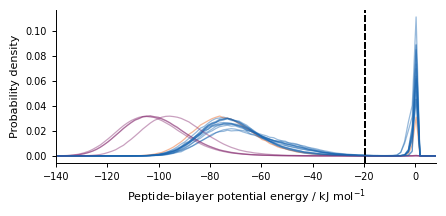

In [10]:
fig, ax = plt.subplots(figsize=(4.5, 2.2))

aas = "ACDEGHILMNPQSTVRK"
bin_width = 1.5
xlim = (-140, 8)

bins = np.arange(xlim[0], xlim[1] + bin_width, bin_width)
mins = []

for aa in aas:
    f1 = f"data/WLXLL/323/Tetralith_WL{aa}LL_pl.npy"
    f2 = f"data/WLXLL/323/Arrhenius_WL{aa}LL_pl.npy"
    ene = np.concatenate([np.load(f1, allow_pickle=True)[1000:], np.load(f2, allow_pickle=True)[1000:]])
    hist, edges = np.histogram(ene, bins=bins, density=True)
    centers = edges[:-1] + 0.5 * np.diff(edges)
    mask = (centers >= -50) & (centers <= -1)
    valid_idx = np.where(mask)[0]
    mins.append(centers[valid_idx[np.argmin(hist[mask])]])
    
    ax.plot(centers, hist, color=aa_color(aa), lw=0.9, alpha=0.45)


    ax.axvline(min_avg, color="black", ls="--", lw=1.2)

ax.set_xlim(*xlim)
ax.set_xlabel("Peptide–bilayer potential energy / kJ mol$^{-1}$")
ax.set_ylabel("Probability density")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 4B

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


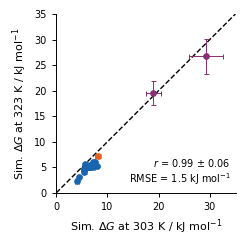

In [11]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))

aa_list = list("ACDEGHILMNPQSTVRK")
s303 = df[df["T"] == "303"].groupby("aa")[["dg", "dg_err"]].mean()
s323 = df[df["T"] == "323"].groupby("aa")[["dg", "dg_err"]].mean()

aas = [a for a in aa_list if a in s303.index and a in s323.index]
x, xerr = s303.loc[aas, "dg"], s303.loc[aas, "dg_err"]
y, yerr = s323.loc[aas, "dg"], s323.loc[aas, "dg_err"]

# Plot Errorbars & Dots
for aa in aas:
    c = aa_color(aa)
    ax.errorbar(x.loc[aa], y.loc[aa], xerr=xerr.loc[aa], yerr=yerr.loc[aa],
                fmt="o", ms=3.8, mec=c, mfc=c, ecolor=c, elinewidth=0.7, capsize=1.8, capthick=0.7, zorder=3)

# Identity Line & Scaling
xlim, ylim = (0, 35), (0, 35)
lin = np.linspace(0, 35, 100)
ax.plot(lin, lin, "k--", lw=1.0, zorder=1)
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="datalim")

# Statistics Text
pr, pr_err, rmse = compute_statistics(x.values, y.values)
stats_str = f"$r$ = {pr:.2f} ± {pr_err:.2f}\nRMSE = {rmse:.1f} kJ mol$^{{-1}}$"
ax.text(0.97, 0.2, stats_str, transform=ax.transAxes, ha="right", va="top", fontsize=7)

ax.set_xlabel(r"Sim. $\Delta G$ at 303 K / kJ mol$^{-1}$")
ax.set_ylabel(r"Sim. $\Delta G$ at 323 K / kJ mol$^{-1}$")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 4C

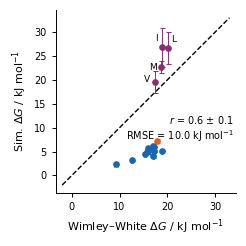

In [12]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))

aa_list = list("ACDEGHILMNPQSTVRK")
exp = df.groupby("aa")[["exp", "exp_error"]].mean()
sub = df.loc[(df["T"] == "323") & (df["aa"].isin(aa_list)), ["aa", "dg", "dg_err"]]
sim = sub.groupby("aa")[["dg", "dg_err"]].mean()

aas = [a for a in aa_list if a in exp.index and a in sim.index]
x, xerr = exp.loc[aas, "exp"], exp.loc[aas, "exp_error"]
y, yerr = sim.loc[aas, "dg"], sim.loc[aas, "dg_err"]

label_aas = {"V", "I", "L", "M"}
label_offsets = {"V": (-6, 2), "I": (-4, 6), "L": (4, 6), "M": (-6, 0)}

for aa in aas:
    c = aa_color(aa)
    ax.errorbar(x.loc[aa], y.loc[aa], xerr=xerr.loc[aa], yerr=yerr.loc[aa],
                fmt="o", ms=3.8, mec=c, mfc=c, ecolor=c, elinewidth=0.7, capsize=1.8, capthick=0.7, zorder=3)
    if aa in label_aas:
        dx, dy = label_offsets.get(aa, (0, 4))
        ax.annotate(aa, (x.loc[aa], y.loc[aa]), xytext=(dx, dy), textcoords="offset points",
                    ha="center", va="center", fontsize=6.5, zorder=4)

#xlim, ylim = (-2, 33), (0, 33)
lin = np.linspace(-2, 33, 100)
ax.plot(lin, lin, "k--", lw=1.0, zorder=1)
#ax.set_xlim(*xlim) 
#ax.set_ylim(*ylim)
ax.set_aspect("equal", adjustable="datalim")

pr, pr_err, rmse = compute_statistics(x.values, y.values)
stats_str = f"$r$ = {pr:.1f} ± {pr_err:.1f}\nRMSE = {rmse:.1f} kJ mol$^{{-1}}$"
ax.text(0.99, 0.43, stats_str, transform=ax.transAxes, ha="right", va="top", fontsize=7)

ax.set_xlabel(r"Wimley–White $\Delta G$ / kJ mol$^{-1}$")
ax.set_ylabel(r"Sim. $\Delta G$ / kJ mol$^{-1}$")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 4D

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


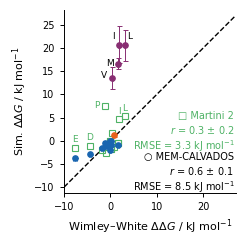

In [13]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))

aa_list = ["A", "C", "D", "E", "G", "H", "I", "L", "N", "P", "Q", "S", "T", "V", "M"]
ref_aa = "A"

exp = df.groupby("aa")[["exp", "exp_error"]].mean()
sim = df.loc[(df["T"] == "323") & (df["aa"].isin(aa_list))].groupby("aa")[["dg", "dg_err"]].mean()

aas = [a for a in aa_list if a in exp.index and a in sim.index]
x = exp.loc[aas, "exp"] - exp.loc[ref_aa, "exp"]
y = sim.loc[aas, "dg"] - sim.loc[ref_aa, "dg"]
xerr = np.sqrt(exp.loc[aas, "exp_error"]**2 + exp.loc[ref_aa, "exp_error"]**2)
yerr = sim.loc[aas, "dg_err"]

label_aas = {"V", "I", "L", "M"}
label_offsets = {"V": (-6, 2), "I": (-4, 6), "L": (4, 6), "M": (-6, 0)}

for aa in aas:
    c = aa_color(aa)
    ax.errorbar(x.loc[aa], y.loc[aa], xerr=xerr.loc[aa], yerr=yerr.loc[aa],
                fmt="o", ms=3.8, mec=c, mfc=c, ecolor=c, elinewidth=0.7, capsize=1.8, capthick=0.7, zorder=3)
    if aa in label_aas:
        dx, dy = label_offsets.get(aa, (0, 4))
        ax.annotate(aa, (x.loc[aa], y.loc[aa]), xytext=(dx, dy), textcoords="offset points",
                    ha="center", va="center", fontsize=6.5, zorder=4)

sub_m = df[df["T"] == "323"].groupby("aa")[["ddg_martini", "exp_ddg"]].mean().reindex(aa_list).dropna()
ox, oy = sub_m["exp_ddg"], sub_m["ddg_martini"]
o_color = rnb_colors["green1"]
o_label_aas = {"L", "I", "P", "E", "D"}
o_offsets = {"L": (0, 6), "I": (0, 6), "P": (-6, 0), "E": (0, 6), "D": (0, 6)}

for aa in ox.index:
    ax.plot(ox.loc[aa], oy.loc[aa], marker="s", ms=4, mfc="none", mec=o_color, mew=0.8, ls="none", zorder=2)
    if aa in o_label_aas:
        dx, dy = o_offsets.get(aa, (0, 4))
        ax.annotate(aa, (ox.loc[aa], oy.loc[aa]), xytext=(dx, dy), textcoords="offset points",
                    ha="center", va="center", fontsize=6.5, zorder=4, color=o_color)

lin = np.linspace(-10, 27, 100)
ax.plot(lin, lin, "k--", lw=1.0, zorder=1)
ax.set_xlim(-10, 27)
ax.set_ylim(-10, 27)
ax.set_aspect("equal", adjustable="datalim")

pr, pr_err, rmse = compute_statistics(x.values, y.values)
pr_o, pr_err_o, rmse_o = compute_statistics(ox.values, oy.values)

text_entries = [
    ("\u25a1 Martini 2", o_color),
    (f"$r$ = {pr_o:.1f} ± {pr_err_o:.1f}", o_color),
    (f"RMSE = {rmse_o:.1f} kJ mol$^{{-1}}$", o_color),
    ("\u25cb MEM-CALVADOS", "black"),
    (f"$r$ = {pr:.1f} ± {pr_err:.1f}", "black"),
    (f"RMSE = {rmse:.1f} kJ mol$^{{-1}}$", "black")
]

x_pos, y_pos, line_height = 0.99, 0.45, 0.075
for i, (line_str, color) in enumerate(text_entries):
    ax.text(x_pos, y_pos - i * line_height, line_str, transform=ax.transAxes, ha="right", va="top", fontsize=7, color=color)

ax.set_xlabel(r"Wimley–White $\Delta\Delta G$ / kJ mol$^{-1}$")
ax.set_ylabel(r"Sim. $\Delta\Delta G$ / kJ mol$^{-1}$")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Figure 4E

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


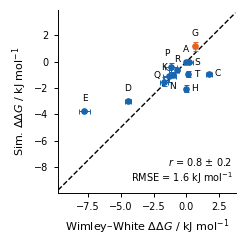

In [14]:
fig, ax = plt.subplots(figsize=(2.5, 2.5))

aa_list = ["A", "Q", "C", "G", "H", "N", "P", "S", "T", "D", "E", "R", "K"]
ref_aa = "A"

exp = df.groupby("aa")[["exp", "exp_error"]].mean()
sim = df.loc[(df["T"] == "323") & (df["aa"].isin(aa_list))].groupby("aa")[["dg", "dg_err"]].mean()

aas = [a for a in aa_list if a in exp.index and a in sim.index]
x = exp.loc[aas, "exp"] - exp.loc[ref_aa, "exp"]
y = sim.loc[aas, "dg"] - sim.loc[ref_aa, "dg"]
xerr = np.sqrt(exp.loc[aas, "exp_error"]**2 + exp.loc[ref_aa, "exp_error"]**2)
yerr = sim.loc[aas, "dg_err"]

label_offsets = {
    "D": (0, 9), "E": (0, 9), "A": (0, 9), "Q": (-5, 4), "R": (0, 7), "C": (6, 0),
    "G": (0, 9), "H": (6, 0), "K": (-4, 6), "N": (0, -8), "P": (-3, 10), "S": (6, 0), "T": (6, 0)
}

for aa in aas:
    c = aa_color(aa)
    ax.errorbar(x.loc[aa], y.loc[aa], xerr=xerr.loc[aa], yerr=yerr.loc[aa],
                fmt="o", ms=3.8, mec=c, mfc=c, ecolor=c, elinewidth=0.7, capsize=1.8, capthick=0.7, zorder=3)
    dx, dy = label_offsets.get(aa, (0, 4))
    ax.annotate(aa, (x.loc[aa], y.loc[aa]), xytext=(dx, dy), textcoords="offset points",
                ha="center", va="center", fontsize=6.5, zorder=4)

lo, hi = min(x.min(), y.min()) - 2, max(x.max(), y.max()) + 2
lin = np.linspace(lo, hi, 100)
ax.plot(lin, lin, "k--", lw=1.0, zorder=1)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_aspect("equal", adjustable="datalim")

pr, pr_err, rmse = compute_statistics(x.values, y.values)
stats_str = f"$r$ = {pr:.1f} ± {pr_err:.1f}\nRMSE = {rmse:.1f} kJ mol$^{{-1}}$"
ax.text(0.98, 0.2, stats_str, transform=ax.transAxes, ha="right", va="top", fontsize=7)

ax.set_xlabel(r"Wimley–White $\Delta\Delta G$ / kJ mol$^{-1}$")
ax.set_ylabel(r"Sim. $\Delta\Delta G$ / kJ mol$^{-1}$")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()